# Day 1.3 — Structured Outputs
Programs need fields, not prose. A **schema** turns the reply into a contract: we describe the
exact shape, ask the model for it, and **validate** before using it. Validation does not make
the model correct; it makes a wrong shape visible instead of letting it leak into the program.

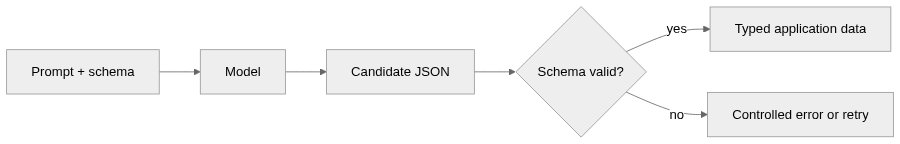

*D02 — prompt plus schema, candidate JSON, validation, typed data or a controlled error*

### Step 1 — Write the contract as a Pydantic model

Pydantic is the standard Python library for "data with rules". Field constraints such as
`ge=0, le=1` are checked automatically.

In [ ]:
from pydantic import BaseModel, Field, ValidationError

class ResearchSummary(BaseModel):
    topic: str
    summary: str
    key_points: list[str] = Field(min_length=1)        # at least one point
    tools_used: list[str] = []
    confidence: float = Field(ge=0.0, le=1.0)          # between 0 and 1

schema = ResearchSummary.model_json_schema()
print(json.dumps(schema, indent=2)[:600], "...")

### Step 2 — Make the schema *strict* and ask for it

Providers enforce a schema only in "strict" form: every object needs `additionalProperties: false`,
every property must be listed as `required`, and constraints they cannot enforce (like `minItems`)
must be removed. We keep the Pydantic model as the real contract and validate on our side regardless.

In [ ]:
def make_strict(node):
    """Recursively convert a Pydantic JSON schema into the strict form providers accept."""
    if isinstance(node, dict):
        if node.get("type") == "object":
            node["additionalProperties"] = False
            node["required"] = list(node.get("properties", {}).keys())
        for key in ("minItems", "maxItems", "minimum", "maximum", "default"):
            node.pop(key, None)
        for value in node.values():
            make_strict(value)
    elif isinstance(node, list):
        for item in node:
            make_strict(item)
    return node

RESEARCH_FORMAT = {"type": "json_schema",
                   "json_schema": {"name": "ResearchSummary", "strict": True, "schema": make_strict(ResearchSummary.model_json_schema())}}

reply = chat([{"role": "user", "content": "Summarize what a tool is in agentic AI."}], response_format=RESEARCH_FORMAT)
print("RAW REPLY:", reply["content"][:300])

### Step 3 — Validate, and explain failures in one line

`model_validate_json` parses and checks in one go. Wrap it so the program gets a typed object
or a readable one-line reason, never a crash.

In [ ]:
def validate_summary(text):
    """Return (ResearchSummary or None, reason)."""
    try:
        return ResearchSummary.model_validate_json(text), "valid"
    except ValidationError as error:
        problems = "; ".join(f"{'.'.join(map(str, e['loc']))}: {e['msg']}" for e in error.errors())
        return None, f"invalid: {problems}"
    except json.JSONDecodeError as error:
        return None, f"not JSON (was the reply cut off by max_tokens?): {error}"

summary, reason = validate_summary(reply["content"])
print("Validation :", reason)
if summary:
    print("Typed data :", summary.topic, "| confidence", summary.confidence, "| points", len(summary.key_points))

### Step 4 — Break it: plausible data that is still invalid

Models occasionally return values a human would accept and the contract does not. We fake one
such reply so the check is deterministic: `confidence` of 4.5 and an empty `key_points` list.

In [ ]:
bad_reply = json.dumps({"topic": "tools", "summary": "A tool is a capability the model may request.",
                        "key_points": [], "tools_used": [], "confidence": 4.5})
summary, reason = validate_summary(bad_reply)
print("Validation :", reason)
print("Typed data :", summary)      # None: nothing downstream can use a bad object by accident

### Checkpoint

**1. Validation passed. Does that mean the summary is factually correct?**

<details><summary>Show answer</summary>

No. Validation checks *shape* (fields, types, ranges). Factual correctness is a separate evaluation; policy (is an action allowed?) is a third check. Keep the three apart.

</details>

**2. Why keep validating in Python when the provider already enforces a strict schema?**

<details><summary>Show answer</summary>

The provider enforces only part of the contract (no `minItems`, no ranges it cannot express), some providers ignore `strict`, and a truncated reply is not JSON at all. Your code is the last line of defence.

</details>

### Recap

- **Limitation seen:** prose replies cannot be consumed by a program.
- **Layer added:** a Pydantic contract, a strict schema in the request, validation on the way in.
- **Evidence:** valid data became a typed object; `confidence=4.5` was rejected with a readable reason.